# Plotter hTPC

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

In [2]:
FIG_SINGLE = (3.34, 2.5)
FIG_DOUBLE = (6.69, 3.5)

plt.rcParams.update({
    # Figure
    "figure.figsize": FIG_SINGLE,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    
    # Colours
    'image.cmap': 'inferno',

    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,

    # Axes labels and titles
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "axes.labelpad": 3,
    "axes.titlepad": 4,

    # Ticks
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.pad": 2,
    "ytick.major.pad": 2,

    # Lines
    "lines.linewidth": 1.0,
    "lines.markersize": 3,

    # Axes appearance
    "axes.linewidth": 0.6,
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",

    # Tick colour
    "xtick.color": "black",
    "ytick.color": "black",

    # Legend
    "legend.fontsize": 6,
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.handletextpad": 0.4,
    "legend.borderaxespad": 0.4,

    # Grid
    "axes.grid": False,
    "grid.color": "0.85",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.8,

    # Export fonts as editable text in vector files
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

### Low Energy ER Spectrum (materials + intrinsics)

In [ ]:
%run gen_energy_plots.py FIG_DOUBLE[0] FIG_DOUBLE[1]

usage: gen_energy_plots.py [-h] fig_height fig_width
gen_energy_plots.py: error: argument fig_height: invalid float value: 'FIG_DOUBLE[0]'


SystemExit: 2

### High Energy ER Spectrum

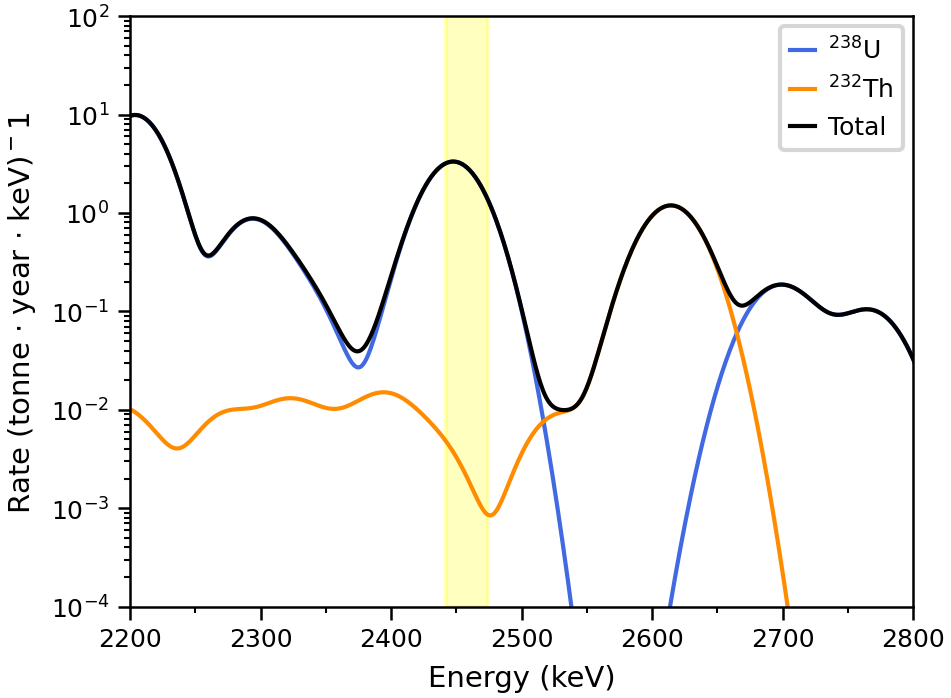

In [ ]:
# ----------
# Functions
# ----------
def energy_res(energy, a_res=0.317, b_res=1.7):
    resolution = a_res*np.sqrt(energy)+b_res*10**-3*energy
    return resolution

def gaussian(x, mu, sig):
    return (
        1.0 / (np.sqrt(2.0 * np.pi) * sig) * np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

def apply_energy_smear(hist, e_edges, bins=1000):

    bw   = e_edges[1] - e_edges[0]
    xs = np.linspace(e_edges[0], e_edges[-1], bins)
    smeared_array = np.zeros(len(xs))

    for idx, val in enumerate(hist):
        E_val = e_edges[idx]
        if E_val != 0:
            sigma = energy_res(E_val)
            fun   = gaussian(xs, E_val, sigma) * val * bw
            smeared_array = np.add(smeared_array,fun)

    return xs, smeared_array

# -----
# Main
# -----
dirpath  = PROJECT_ROOT / "common_plots" / "data"
npfile   = np.load(dirpath / "high_e_inner.npz")
e_edges  = npfile["e_edges"]
hist_arr = npfile["hist_arr"]

spectra = []
for idx in range(0,2):
    hist = hist_arr[idx]
    spectra.append(hist)

total = np.sum(spectra, axis=0)

fig, ax = plt.subplots()

labels = ["U238", "Th232"]
for idx, spectrum in enumerate(spectra[:2]):
    xs, smeared_hist = apply_energy_smear(spectrum, e_edges)
    ax.plot(
        xs, 
        smeared_hist , 
        label=isotope_dict[labels[idx]]["tex"], 
        color=isotope_dict[labels[idx]]["color"])

xs, smeared_hist = apply_energy_smear(total, e_edges)
ax.plot(xs, smeared_hist, label="Total", color='black')
ax.set_xlabel("Energy (keV)")
ax.set_ylabel(rf"Rate (tonne $\cdot$ year $\cdot$ keV)$^{-1}$")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1e2)
ax.set_xlim(2200, 2800)
xticks = np.arange(2200, 2800, 50)
ax.set_xticks(xticks, minor=True)
ax.axvspan(2458-16, 2458+16, alpha=0.25, color='yellow')
#ax.text(3.2, 70, r'WIMP ROI', fontsize=8)
ax.legend(
loc="upper right",
ncol=1,
frameon=True,
fontsize=6,
columnspacing=0.3,
handlelength=1,
handletextpad=0.5,
borderpad=0.4,
)
plt.tight_layout();

In [56]:
FIG_DOUBLE[0]

6.69

## ER NR Efficiency

In [ ]:
import h5py
hdf = h5py.File("data/sens_plot_data.hdf5", "r")

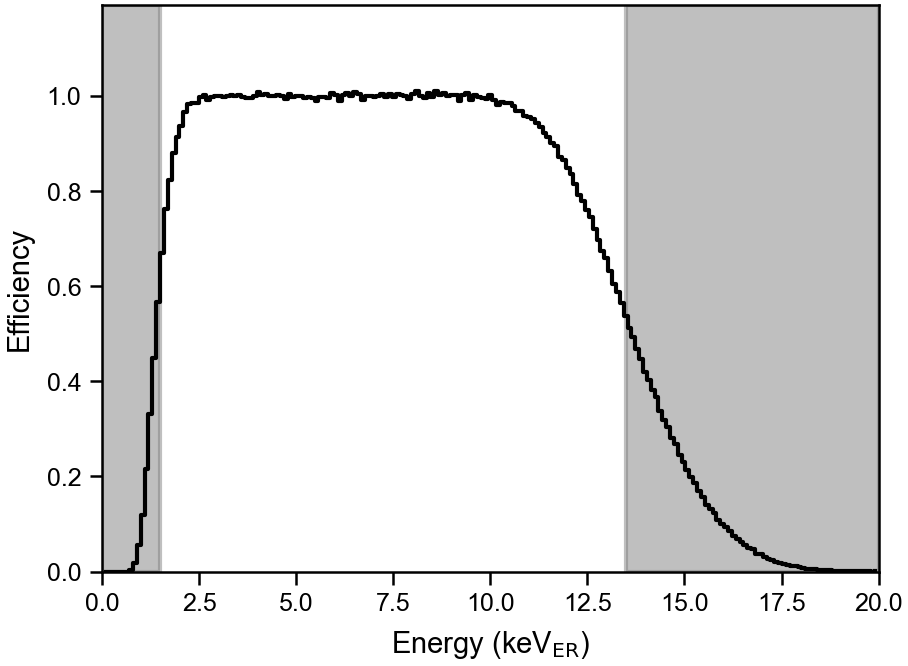

In [18]:
h = hdf["efficiency_ER"]
energy_05_low = 1.5
energy_05_high = 13.5

plt.step(h[0], h[1], where="post", color="black")

plt.axvspan(0, energy_05_low, color="gray", alpha=0.5, zorder=0)
plt.axvspan(energy_05_high, 20, color="gray", alpha=0.5, zorder=0)

plt.xlim(0, 20)
plt.ylim(0, 1.19)

plt.ylabel("Efficiency")
plt.xlabel("Energy (keV$_{\mathrm{ER}}$)")

plt.show()

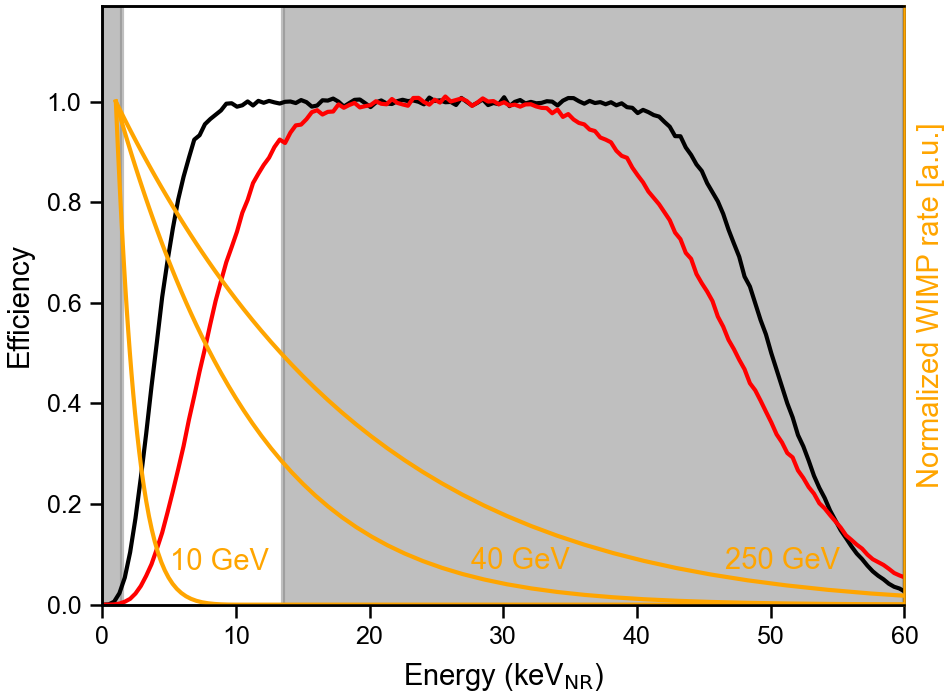

In [21]:
h = hdf["efficiency_NR"]
h_30p = hdf["efficiency_NR_30p"]

fig = plt.figure()

ax1 = plt.gca()
ax1.plot(h[0], h[1], ls="-", color="black", label="Efficiency")
ax1.plot(h_30p[0], h_30p[1], ls="-", color="red", label="Efficiency 30\% abs.")
ax1.set_ylabel("Efficiency")
ax1.set_ylim(0, 1.19)

# Create a second y-axis on the right for the WIMP spectra
ax2 = ax1.twinx()
ax2.spines["right"].set_color("orange")
ax2.yaxis.label.set_color("orange")
#ax2.tick_params(axis="y", colors="orange")
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylabel("Normalized WIMP rate [a.u.]", color="orange")
ax2.set_ylim(0, 1.19)

mws = [10, 40, 250]
# Put WIMP spectra on the right axis
for mw in mws:
    x,y = hdf[f"WIMP_rate_{mw}GeV"][:]
    ax2.plot(x, y, "-", color="orange")
    # find energy where rate goes below 0.1
    idx = np.where(y < 0.1)[0][0]
    ax2.text(x[idx]*1.15, y[idx], f"{mw} GeV", color="orange", va="center", ha="left")

ax1.set_xlim(0, 60)
ax1.set_xlabel("Energy (keV$_{\mathrm{NR}}$)")

ax1.axvspan(0, energy_05_low, color="gray", alpha=0.5, zorder=0)
ax1.axvspan(energy_05_high, 60, color="gray", alpha=0.5, zorder=0)

plt.tight_layout()

plt.show()

## WIMP sensitivity limits

In [ ]:
import h5py
hdf = h5py.File("data/sens_plot_data.hdf5", "r")

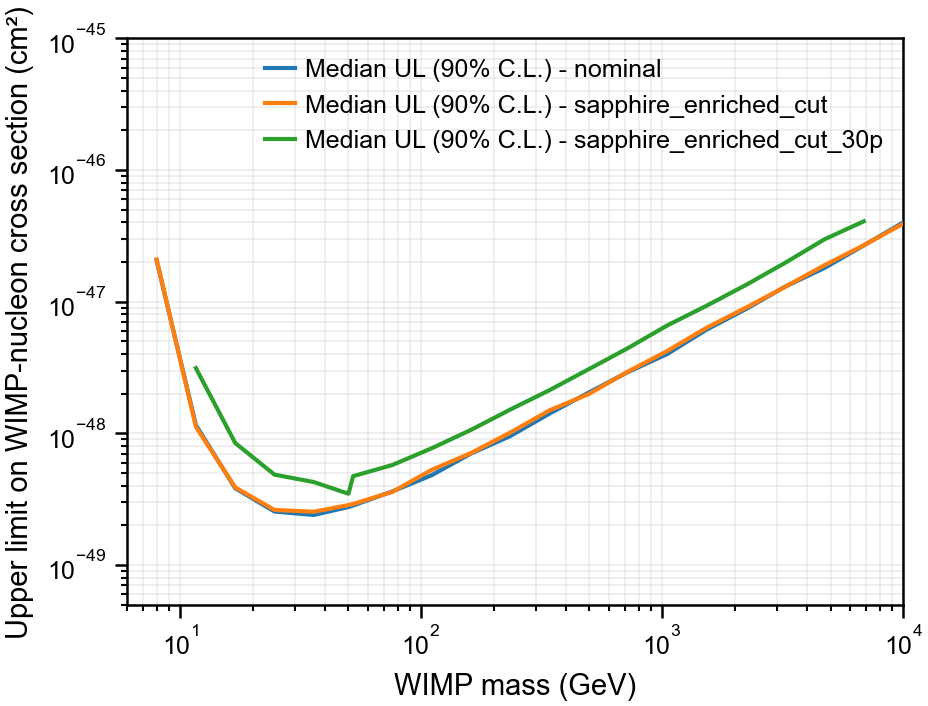

In [23]:
# Plot the limits as a function of WIMP mass
ref_xsec = 1e-48 # cm^2

fig = plt.figure()

keys = ["nominal", "sapphire_enriched_cut", "sapphire_enriched_cut_30p"]

for key in keys:
    if key in hdf:
        masses, ul_median = hdf[key][:]
        plt.plot(masses, ul_median, label=f"Median UL (90% C.L.) - {key}", zorder=3)

plt.ylim(5e-50, 1e-45)
plt.xlim(6, 1e4)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("WIMP mass (GeV)")
plt.ylabel("Upper limit on WIMP-nucleon cross section (cm²)")

plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()